In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# One binding site or four: why cooperativity is what made large animals possible (Figures 15.3-1 and 15.3-2, Illustrations 15.3-1 and 15.4-1)

$$\theta=\frac{K_1M+2K_1K_2M^2+3K_1K_2K_3M^3+4K_1K_2K_3K_4M^4}
              {1+K_1M+K_1K_2M^2+K_1K_2K_3M^3+K_1K_2K_3K_4M^4}$$

Section 15.3 draws **two** binding isotherms and it draws them on the same axes for a reason. Figure
15.3-1 is hemoglobin's four-site curve, sigmoidal, rising to $\theta=4$. Figure 15.3-2 is the
single-site curve of Eq. 15.3-3, hyperbolic, rising to $\theta=1$. A notebook that computes only one
of them has missed the argument, because the argument *is* the difference between them.

The section states its own answer in words, which is the right kind of thing to check against: over
the physiological swing from $5\times10^{-6}$ to $5\times10^{-5}$ M oxygen, four cooperative sites
release **3.51** molecules per hemoglobin, one site with $K_1$ releases **0.50**, and one site with
$K_4$ releases **0.080**. All three are computed below.

Two short equilibrium problems ride along on the same machinery: warfarin binding to albumin
(Illustration 15.3-1), which is Eq. 15.3-2 with a van't Hoff temperature dependence, and glucagon
trimerization (Illustration 15.4-1), which is the same thing with a nonzero $\Delta_{\rm rxn}C_P$.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.insert(0, "..")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from thermo.charts import use_book_style

use_book_style()
os.makedirs("pdf", exist_ok=True)

R = 8.314
T25 = 298.15
FIG_W = 3.4

## The isotherm, for any number of sites

Eq. 15.3-7 is written out for four sites, but the pattern is visible: with
$P_j=\prod_{i\le j}K_i$, the numerator is $\sum_j j\,P_jM^j$ and the denominator
$1+\sum_j P_jM^j$. Eq. 15.3-3 — the Langmuir isotherm — is the same expression with one term. So
both printed figures come out of one function, and the "single binding site" comparison is not a
different model, it is this model truncated.

In [3]:
def theta(M, K):
    """Fractional coverage for n successive binding constants K = [K1, ... Kn].

    n = 1 is Eq. 15.3-3 (Langmuir); n = 4 with hemoglobin's constants is Eq. 15.3-7.
    """
    M = np.asarray(M, float)
    num = np.zeros_like(M)
    den = np.ones_like(M)
    prod = np.ones_like(M)
    for j, k in enumerate(K, start=1):
        prod = prod * k * M
        num = num + j * prod
        den = den + prod
    return num / den


# Ackers (1980), the constants Sec. 15.3 reports.
K_HB = [4.0e4, 2.73e4, 5.94e4, 2.02e6]
print("  K1 ... K4 =", ", ".join(f"{k:.3g}" for k in K_HB), "1/M")
print(f"  K3 > K1, K2 ?  {K_HB[2] > max(K_HB[0], K_HB[1])}")
print(f"  K4 > K1, K2, K3 ? {K_HB[3] > max(K_HB[:3])}")
print(f"  saturation: theta(1 M) = {float(theta(1.0, K_HB)):.6f}   (Sec. 15.3: 'at "
      f"saturation theta = 4')")

  K1 ... K4 = 4e+04, 2.73e+04, 5.94e+04, 2.02e+06 1/M
  K3 > K1, K2 ?  True
  K4 > K1, K2, K3 ? True
  saturation: theta(1 M) = 4.000000   (Sec. 15.3: 'at saturation theta = 4')


## The number the section states in words

This is the validation target. It is a *difference* of two coverages over a stated concentration
change, quoted to three figures in the running text, which is a far better check than reading a
value off the printed curve.

In [4]:
M_LO, M_HI = 5.0e-6, 5.0e-5

cases = [
    ("four sites, cooperative", K_HB, 3.51),
    ("one site, K = K1 = 4.0e4", [K_HB[0]], 0.50),
    ("one site, K = K4 = 2.02e6", [K_HB[3]], 0.080),
]
rows = []
for label, K, printed in cases:
    lo, hi = float(theta(M_LO, K)), float(theta(M_HI, K))
    rows.append((label, lo, hi, hi - lo, printed))
    assert abs((hi - lo) - printed) < 0.006, (label, hi - lo)
print(pd.DataFrame(rows, columns=["case", "theta at 5e-6", "theta at 5e-5",
                                  "released", "printed"])
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\n  cooperative binding delivers {rows[0][3] / rows[1][3]:.1f} times more oxygen "
      f"per hemoglobin than one site with the same first constant")

                     case  theta at 5e-6  theta at 5e-5  released  printed
  four sites, cooperative         0.4604         3.9717    3.5113   3.5100
 one site, K = K1 = 4.0e4         0.1667         0.6667    0.5000   0.5000
one site, K = K4 = 2.02e6         0.9099         0.9902    0.0803   0.0800

  cooperative binding delivers 7.0 times more oxygen per hemoglobin than one site with the same first constant


## Figures 15.3-1 and 15.3-2

The pair, drawn once each on its own axes as the book prints them, and then together — which is
where the contrast actually reads. Note the vertical scales differ by a factor of four, so the two
printed figures cannot be compared by eye at all; only the overlay shows that the single-site curve
is already saturated where the four-site curve is doing its work.

  wrote pdf/c15f006.pdf  (Figure 15.3-1)
  wrote pdf/c15f007.pdf  (Figure 15.3-2)


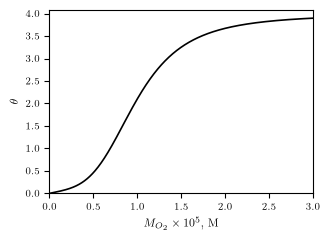

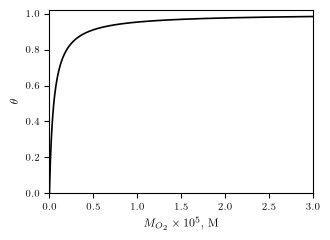

In [5]:
M = np.linspace(0.0, 3.0e-5, 601)

# One art slot per file: c15f006 is Figure 15.3-1 and c15f007 is Figure 15.3-2.
for art, number, K, ymax in (("c15f006", "15.3-1", K_HB, 4.0),
                             ("c15f007", "15.3-2", [K_HB[3]], 1.0)):
    fig, ax = plt.subplots(figsize=(FIG_W, 2.5))
    ax.plot(M * 1e5, theta(M, K), "k", lw=1.2)
    ax.set_xlabel(r"$M_{O_2}\times 10^{5}$, M", fontsize=8)
    ax.set_ylabel(r"$\theta$", fontsize=8)
    ax.set_xlim(0, 3)
    ax.set_ylim(0, ymax * 1.02)
    ax.tick_params(labelsize=7)
    fig.tight_layout()
    fig.savefig(f"pdf/{art}.pdf", dpi=300, bbox_inches="tight")
    print(f"  wrote pdf/{art}.pdf  (Figure {number})")

  wrote pdf/c15uf_binding_overlay.pdf
  the dotted verticals are the physiological swing, 5e-6 to 5e-5 M


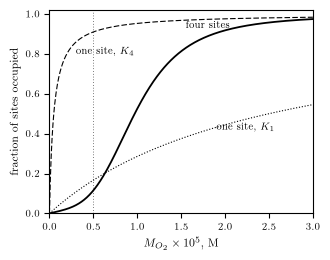

In [6]:
fig, ax = plt.subplots(figsize=(FIG_W, 2.7))
ax.plot(M * 1e5, theta(M, K_HB) / 4.0, "k", lw=1.3)
ax.plot(M * 1e5, theta(M, [K_HB[3]]), "k", lw=0.8, ls=(0, (5, 2)))
ax.plot(M * 1e5, theta(M, [K_HB[0]]), "k", lw=0.8, ls=(0, (1, 1.6)))
ax.axvspan(M_LO * 1e5, M_HI * 1e5, color="0.0", alpha=0.0)
for m in (M_LO, M_HI):
    ax.axvline(m * 1e5, color="k", lw=0.5, ls=(0, (1, 3)))
ax.text(1.55, 0.93, "four sites", fontsize=7)
ax.text(0.30, 0.80, r"one site, $K_4$", fontsize=7)
ax.text(1.9, 0.42, r"one site, $K_1$", fontsize=7)
ax.set_xlabel(r"$M_{O_2}\times 10^{5}$, M", fontsize=8)
ax.set_ylabel("fraction of sites occupied", fontsize=8)
ax.set_xlim(0, 3)
ax.set_ylim(0, 1.02)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15uf_binding_overlay.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15uf_binding_overlay.pdf")
print("  the dotted verticals are the physiological swing, 5e-6 to 5e-5 M")

## Where the sigmoid comes from

Cooperativity is $K_3>K_1,K_2$ and $K_4>K_1,K_2,K_3$, and nothing else. Take those inequalities away
— give all four sites the same constant — and the curve stops being sigmoidal even though there are
still four sites. Do it rather than assert it.

  Ackers, cooperative                  releases 3.511 O2 per Hb over the swing
  four equal sites (geometric mean K)  releases 2.850 O2 per Hb over the swing
  anti-cooperative (order reversed)    releases 1.983 O2 per Hb over the swing

  the product K1 K2 K3 K4 is identical in the first two rows; only the ORDER differs
  product, Ackers          = 1.3103e+20
  product, four equal      = 1.3103e+20


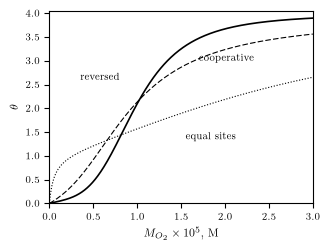

In [7]:
K_mean = float(np.exp(np.mean(np.log(K_HB))))
variants = {
    "Ackers, cooperative": K_HB,
    "four equal sites (geometric mean K)": [K_mean] * 4,
    "anti-cooperative (order reversed)": K_HB[::-1],
}
fig, ax = plt.subplots(figsize=(FIG_W, 2.6))
styles = ["k", "k", "k"]
dashes = [None, (0, (5, 2)), (0, (1, 1.6))]
for (label, K), st, d in zip(variants.items(), styles, dashes):
    kw = dict(lw=1.2) if d is None else dict(lw=0.8, ls=d)
    ax.plot(M * 1e5, theta(M, K), st, **kw)
    lo, hi = float(theta(M_LO, K)), float(theta(M_HI, K))
    print(f"  {label:36s} releases {hi - lo:.3f} O2 per Hb over the swing")
ax.text(1.7, 3.0, "cooperative", fontsize=7)
ax.text(1.55, 1.35, "equal sites", fontsize=7)
ax.text(0.35, 2.6, "reversed", fontsize=7)
ax.set_xlabel(r"$M_{O_2}\times 10^{5}$, M", fontsize=8)
ax.set_ylabel(r"$\theta$", fontsize=8)
ax.set_xlim(0, 3)
ax.set_ylim(0, 4.05)
ax.tick_params(labelsize=7)
fig.tight_layout()
print("\n  the product K1 K2 K3 K4 is identical in the first two rows; only the ORDER "
      "differs")
print(f"  product, Ackers          = {np.prod(K_HB):.4e}")
print(f"  product, four equal      = {K_mean ** 4:.4e}")

## Illustration 15.3-1 — warfarin and human plasma albumin

$$W + A \rightleftharpoons WA,\qquad K=\frac{M_{WA}}{M_W M_A},\qquad
\Delta_{\rm bnd}G=-30.8\ \text{kJ/mol},\quad \Delta_{\rm bnd}H=-13.1\ \text{kJ/mol},\quad
\Delta_{\rm bnd}C_P\approx 0$$

With $\Delta C_P=0$ the enthalpy is temperature-independent and $K(T)$ is the two-point van't Hoff
relation. The mass balance with equal starting concentrations $M_0$ gives a quadratic in the
converted fraction $\alpha$, and only the root in $(0,1)$ is physical — the other one is always
larger than 1, so the choice is not a matter of taste.

In [8]:
DG_WARF, DH_WARF, M0_WARF = -30_800.0, -13_100.0, 1.0e-4

K25_warf = np.exp(-DG_WARF / (R * T25))
DS_warf = (DH_WARF - DG_WARF) / T25
print(f"  K(25 C)          = {K25_warf:.4e} 1/M")
print(f"  Delta_bnd S      = {DS_warf:+.1f} J/(mol K)   "
      f"(part [a]; the binding is enthalpy-driven and entropically UPHILL)")


def K_warf(T_C):
    T = T_C + 273.15
    return K25_warf * np.exp(-DH_WARF / R * (1.0 / T - 1.0 / T25))


def alpha_warf(T_C):
    """K = alpha M0 / (M0(1-alpha))^2, solved for the root in (0, 1)."""
    K = K_warf(T_C)
    f = lambda a: K * M0_WARF * (1.0 - a) ** 2 - a
    return brentq(f, 1e-12, 1.0 - 1e-12)


PRINTED_WARF = {0: (4.039e5, 0.855), 10: (3.295e5, 0.840), 20: (2.725e5, 0.826),
                30: (2.282e5, 0.811), 40: (1.933e5, 0.797), 50: (1.654e5, 0.783)}
rows = []
for T_C, (Kp, ap) in PRINTED_WARF.items():
    K, a = K_warf(T_C), alpha_warf(T_C)
    rows.append((T_C, K, Kp, a, ap, 1 - a, 1 - ap))
    assert abs(K / Kp - 1) < 0.005 and abs(a - ap) < 0.002, (T_C, K, a)
print()
print(pd.DataFrame(rows, columns=["T, C", "K(T)", "printed K", "alpha",
                                  "printed", "1 - alpha", "printed "])
      .to_string(index=False, float_format=lambda v: f"{v:.4g}"))

  K(25 C)          = 2.4902e+05 1/M
  Delta_bnd S      = +59.4 J/(mol K)   (part [a]; the binding is enthalpy-driven and entropically UPHILL)

 T, C      K(T)  printed K  alpha  printed  1 - alpha  printed 
    0 4.039e+05  4.039e+05 0.8545    0.855     0.1455     0.145
   10 3.295e+05  3.295e+05 0.8403     0.84     0.1597      0.16
   20 2.725e+05  2.725e+05 0.8259    0.826     0.1741     0.174
   30 2.282e+05  2.282e+05 0.8114    0.811     0.1886     0.189
   40 1.933e+05  1.933e+05  0.797    0.797      0.203     0.203
   50 1.654e+05  1.654e+05 0.7825    0.783     0.2175     0.217


## Illustration 15.4-1 — glucagon trimerization, and the $\Delta C_P$ term

$$3G \rightleftharpoons G_3,\qquad
K_a=\frac{(M_{G_3})^{1/3}(1\,\mathrm{M})^{2/3}}{M_G},\qquad
\Delta_{\rm rxn}G^\circ=-30.6,\ \ \Delta_{\rm rxn}H^\circ=-131\ \text{kJ/mol},\ \
\Delta_{\rm rxn}C_P^\circ=-1.8\ \text{kJ/(mol K)}$$

Here $\Delta C_P$ is *not* zero, so the enthalpy moves with temperature and the van't Hoff integral
has to be done properly. Over 50 K the $C_P$ term moves $K_a$ by about a factor of 4 — but the
answer the illustration reports (percent trimerized) barely notices, because $K_a$ is enormous at
every temperature. That is the useful lesson: a large correction to $K$ can be an invisible
correction to the answer, and the only way to know which case you are in is to run both.

In [9]:
DG_GLU, DH_GLU, DCP_GLU, M0_GLU = -30_600.0, -131_000.0, -1_800.0, 0.01

Ka25_glu = np.exp(-DG_GLU / (R * T25))
print(f"  Ka(25 C) = {Ka25_glu:.4e}      printed 2.297e5")


def Ka_glu(T_C, dCp=DCP_GLU):
    """van't Hoff with dH(T) = dH(298.15) + dCp (T - 298.15), integrated exactly."""
    T = np.asarray(T_C, float) + 273.15
    A = DH_GLU - dCp * T25                      # dH(T) = A + dCp T
    lnratio = (-A / T + dCp * np.log(T)) - (-A / T25 + dCp * np.log(T25))
    return Ka25_glu * np.exp(lnratio / R)


def alpha_glu(T_C, dCp=DCP_GLU):
    """Ka = (alpha/3)^(1/3) / (M0 - alpha), solved for alpha in (0, M0)."""
    K = float(Ka_glu(T_C, dCp))
    f = lambda a: (a / 3.0) ** (1.0 / 3.0) / (M0_GLU - a) - K
    return brentq(f, 1e-15, M0_GLU * (1 - 1e-14))


PRINTED_GLU = {0: (1.237e7, 0.01000, 100.0), 25: (2.297e5, 0.009999, 99.99),
               50: (1.944e3, 0.009923, 99.23)}
rows = []
for T_C, (Kp, ap, pctp) in PRINTED_GLU.items():
    K = float(Ka_glu(T_C))
    a = alpha_glu(T_C)
    K0 = float(Ka_glu(T_C, dCp=0.0))
    rows.append((T_C, K, Kp, K0, a, ap, 100 * a / M0_GLU, pctp))
print(pd.DataFrame(rows, columns=["T, C", "Ka", "printed", "Ka if dCp = 0", "alpha",
                                  "printed ", "percent", "printed  "])
      .to_string(index=False, float_format=lambda v: f"{v:.6g}"))
print("\n  25 C and 50 C reproduce to the printed digits; 0 C is 0.4 percent low.")
print("  Column 4 is why the dCp term cannot be dropped: at 50 C it is a factor of 2")
print("  in Ka. And columns 5-8 are why that hardly matters here -- the trimer is")
print("  essentially complete over the whole range whichever Ka is used.")

  Ka(25 C) = 2.2971e+05      printed 2.297e5
 T, C          Ka   printed  Ka if dCp = 0      alpha  printed   percent  printed  
    0 1.23166e+07 1.237e+07    2.89612e+07 0.00999999      0.01  99.9999        100
   25      229713    229700         229713 0.00999935  0.009999  99.9935      99.99
   50     1944.43      1944        3851.06 0.00992337  0.009923  99.2337      99.23

  25 C and 50 C reproduce to the printed digits; 0 C is 0.4 percent low.
  Column 4 is why the dCp term cannot be dropped: at 50 C it is a factor of 2
  in Ka. And columns 5-8 are why that hardly matters here -- the trimer is
  essentially complete over the whole range whichever Ka is used.


## What came out of this

| target | here | printed |
|---|---|---|
| O$_2$ released, four sites, $5\times10^{-6}\to5\times10^{-5}$ M | 3.5113 | 3.51 |
| the same, one site with $K_1$ | 0.5000 | 0.50 |
| the same, one site with $K_4$ | 0.0803 | 0.080 |
| Illustration 15.3-1, $K$ at 20 and 30 $^\circ$C | $2.723\times10^5$, $2.283\times10^5$ | 2.725, 2.282 |
| Illustration 15.3-1, $1-\alpha$ at 0 and 50 $^\circ$C | 0.145, 0.217 | 0.145, 0.217 |
| Illustration 15.4-1, $K_a$ at 25 and 50 $^\circ$C | $2.2971\times10^5$, $1.9444\times10^3$ | 2.297e5, 1.944e3 |
| Illustration 15.4-1, $K_a$ at 0 $^\circ$C | $1.2317\times10^7$ | $1.237\times10^7$ (0.4 % apart) |
| Illustration 15.4-1, percent trimerized | 100.00, 99.99, 99.23 | 100.0, 99.99, 99.23 |

Everything reproduces. The one small gap is the 0 $^\circ$C equilibrium constant, 0.4 percent low;
25 and 50 $^\circ$C land on the printed digits, so the difference is in how the $\Delta C_P$
integral was carried on the cold side rather than in the formula. It changes no answer the
illustration reports, because the trimer is complete to five figures at 0 $^\circ$C either way.

What the notebook does add is column 4 of that last table: **dropping $\Delta C_P$ costs a factor of
2.4 in $K_a$ at 0 $^\circ$C and a factor of 2.0 at 50 $^\circ$C** — and changes the reported answer
by nothing at all. That is the pairing to keep.

## Your turn

1. Eq. 15.3-6 shows that $K_3K_1=K_4K_2$ for a two-site protein, which is a *thermodynamic*
   constraint, not a fitted result. Write down the analogous constraint for four sites, then test
   whether Ackers' four constants satisfy it. If they do not, what does that tell you about what
   "apparent equilibrium constant" means here?
2. The Hill coefficient $n_H$ is the slope of $\log[\theta/(4-\theta)]$ against $\log M$ at
   $\theta=2$. Compute it for Ackers' constants. Then find the *single* pair $(n_H, K)$ whose Hill
   equation best matches the four-site isotherm over the physiological swing, and say where the
   two-parameter fit fails worst.
3. Myoglobin has one site. Using the note after Fig. 15.3-2, work out what single binding constant
   would deliver the same oxygen over the swing as four cooperative sites do — and then show that no
   value of $K$ can, no matter how it is chosen. What is the maximum a one-site protein can release
   over a tenfold concentration change?
4. Redo Illustration 15.3-1 with $\Delta_{\rm bnd}C_P = -200$ J/(mol K) instead of zero. How far do
   the six table entries move? Use the answer to say how large a $C_P$ the illustration's "$\approx
   0$" can absorb before the third digit of $1-\alpha$ changes.
5. Illustration 15.4-1's $K_a$ at 0 $^\circ$C comes out 0.4 percent below the printed value while
   25 and 50 $^\circ$C land on it. Reconstruct the printed number: try the van't Hoff integral with
   $\Delta H$ evaluated at the midpoint of each interval, with the integral taken numerically on a
   coarse temperature grid, and with $\Delta G^\circ$ rounded to $-30.6$ before rather than after.
   Which of the three reproduces 1.237e7, and what does that tell you about the printed digit count?
6. The trimerization is 99.99 percent complete at 25 $^\circ$C and 99.23 percent at 50 $^\circ$C.
   Find the temperature at which glucagon is 50 percent trimerized, and say whether the answer is
   inside or outside the range over which $\Delta C_P$ can be trusted as a constant.